# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

In [259]:
import math
# Imports
import copy
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
import random
from matplotlib.ticker import FuncFormatter
from statistics import mean

import scipy.special
from tqdm import tqdm
import shutil
from joblib import Parallel, delayed
from scipy.special import factorial
import powerlaw
from NEMtropy import UndirectedGraph
from matplotlib.colors import LinearSegmentedColormap


In [2]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_RED = 'lightcoral'
COLOR_GREY = 'slategrey'
COLOR_BLACK = 'black'
COLOR_LIGHT_GRAY = 'lightgray'
COLOR_DARK_GRAY = 'darkgray'

# Define the main data directory
OUTPUT_PATH = "./output"

In [3]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
OUTPUT_PATH_ER = os.path.join(OUTPUT_PATH, "erdos_renyi_avg_clustering")


# Recreate the subdirectories
os.makedirs(OUTPUT_PATH_ER)

In [33]:
# Define the directory containing the .gml files
directory = 'assignment_03_data'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files:  50%|█████     | 1/2 [00:00<00:00,  6.32it/s]

Finished loading graph_eu_airlines


Loading GML Files: 100%|██████████| 2/2 [00:00<00:00,  2.72it/s]

Finished loading graph_power


In [5]:
# Define the directory containing the .gml files
directory = 'assignment_03_data/World_Trade_Web'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.graphml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs_wtn = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML WTW Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()

            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.txt.graphml$', file_path)
            if match:
                graph_name = match.group(1)

                # Add to the graph dictionary
                graph = nx.read_graphml(file_path)
                graphs_wtn[graph_name] = graph

                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")

        pbar.update(1)  # Update the progress bar

Loading GML WTW Files:   9%|▉         | 1/11 [00:00<00:03,  3.17it/s]

Finished loading WDN_1997
Finished loading WDN_1992


Loading GML WTW Files:  27%|██▋       | 3/11 [00:00<00:02,  3.53it/s]

Finished loading WDN_2000


Loading GML WTW Files:  36%|███▋      | 4/11 [00:01<00:02,  3.39it/s]

...

Finished loading WDN_1995


Loading GML WTW Files:  91%|█████████ | 10/11 [00:03<00:00,  3.10it/s]

Finished loading WDN_1999


Loading GML WTW Files: 100%|██████████| 11/11 [00:03<00:00,  3.26it/s]

Finished loading WDN_2001


# I ERGMs

In [6]:
graphs

{'graph_eu_airlines': <networkx.classes.graph.Graph at 0x11e1bbf10>,
 'graph_power': <networkx.classes.graph.Graph at 0x11e5b3f90>}

In [7]:
graphs_wtn

{'WDN_1997': <networkx.classes.digraph.DiGraph at 0x11f440050>,
 'WDN_1992': <networkx.classes.digraph.DiGraph at 0x11ec52950>,
 'WDN_2000': <networkx.classes.digraph.DiGraph at 0x11f90eb50>,
 'WDN_1998': <networkx.classes.digraph.DiGraph at 0x11f1c3b90>,
 'WDN_1994': <networkx.classes.digraph.DiGraph at 0x11e3fc790>,
 'WDN_1993': <networkx.classes.digraph.DiGraph at 0x11ee52f90>,
 'WDN_2002': <networkx.classes.digraph.DiGraph at 0x1207bcd50>,
 'WDN_1996': <networkx.classes.digraph.DiGraph at 0x11f079690>,
 'WDN_1995': <networkx.classes.digraph.DiGraph at 0x120a54290>,
 'WDN_1999': <networkx.classes.digraph.DiGraph at 0x121222310>,
 'WDN_2001': <networkx.classes.digraph.DiGraph at 0x12138b610>}

## 1. Compute the strength assortativity coefficient on the data.
Hint: Pay attention: the underlying data (WTW) are weighted and direted, meaning you should account
for four different kind of assortativity: in–in, in–out, out–in, out–out.

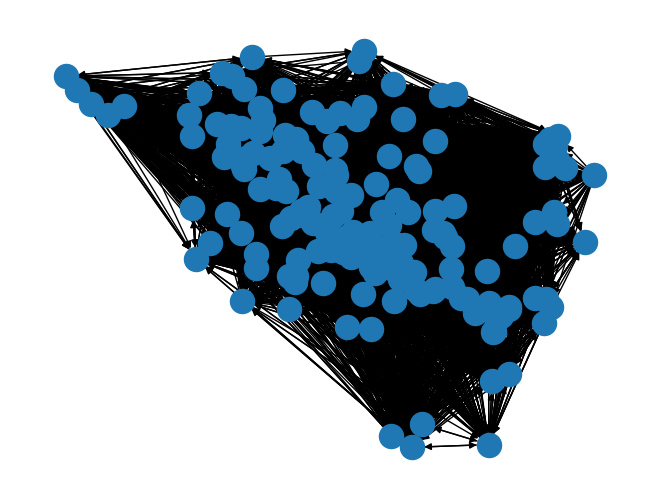

In [8]:
nx.draw(G=graphs_wtn["WDN_1997"])

In [9]:
for graph_name, graph in graphs_wtn.items():
    pass

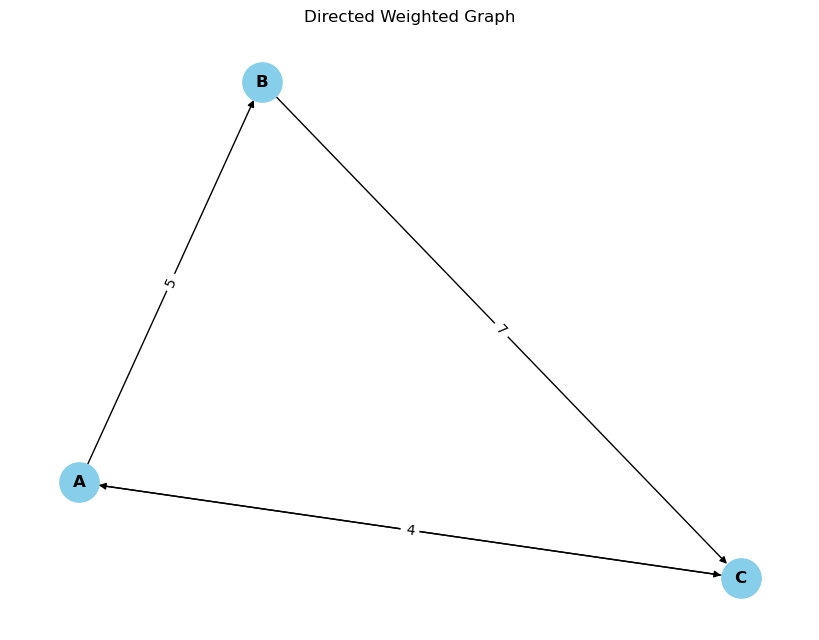

In [10]:
G = nx.DiGraph()

# Add weighted edges
G.add_edge('A', 'B', weight=5)
G.add_edge('A', 'C', weight=3)
G.add_edge('B', 'C', weight=7)
G.add_edge('C', 'A', weight=4)

# Plot the graph
plt.figure(figsize=(8, 6))

pos = nx.spring_layout(G, seed=42)  # Set the layout for consistent plotting

# Draw nodes and labels
nx.draw(G, pos, with_labels=True, node_size=800, node_color='skyblue', font_weight='bold')

# Draw edge labels with weights
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title('Directed Weighted Graph')
plt.show()

In [11]:
def calculate_assortativity(graph):
    in_in = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='in', y='in', weight='weight')
    in_out = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='in', y='out', weight='weight')
    out_in = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='out', y='in', weight='weight')
    out_out = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='out', y='out', weight='weight')

    # Create a dictionary to store assortativity values
    assortativity_dict = {
        "In-In Assortativity": in_in,
        "In-Out Assortativity": in_out,
        "Out-In Assortativity": out_in,
        "Out-Out Assortativity": out_out
    }

    # Return dictionary with assortativity values
    return assortativity_dict

In [12]:
assortativities = {}
for graph_name, graph in graphs_wtn.items():
    assortativities[graph_name] = calculate_assortativity(graph=graph)
    
print(assortativities)

{'WDN_1997': {'In-In Assortativity': -0.073686352073877, 'In-Out Assortativity': -0.07132955497657789, 'Out-In Assortativity': -0.07171683897072376, 'Out-Out Assortativity': -0.06970079872009399}, 'WDN_1992': {'In-In Assortativity': -0.04868776409103533, 'In-Out Assortativity': -0.04664740434092387, 'Out-In Assortativity': -0.059869793086991335, 'Out-Out Assortativity': -0.05760318920541264}, 'WDN_2000': {'In-In Assortativity': -0.06319707174975389, 'In-Out Assortativity': -0.06467170213846347, 'Out-In Assortativity': -0.06539073425903165, 'Out-Out Assortativity': -0.06730072607061888}, 'WDN_1998': {'In-In Assortativity': -0.06557057818395721, 'In-Out Assortativity': -0.06540616504184192, 'Out-In Assortativity': -0.06572057397949528, 'Out-Out Assortativity': -0.06583617855060356}, 'WDN_1994': {'In-In Assortativity': -0.07868988970611882, 'In-Out Assortativity': -0.07622523439269806, 'Out-In Assortativity': -0.08022501617948048, 'Out-Out Assortativity': -0.07800143058821395}, 'WDN_1993'

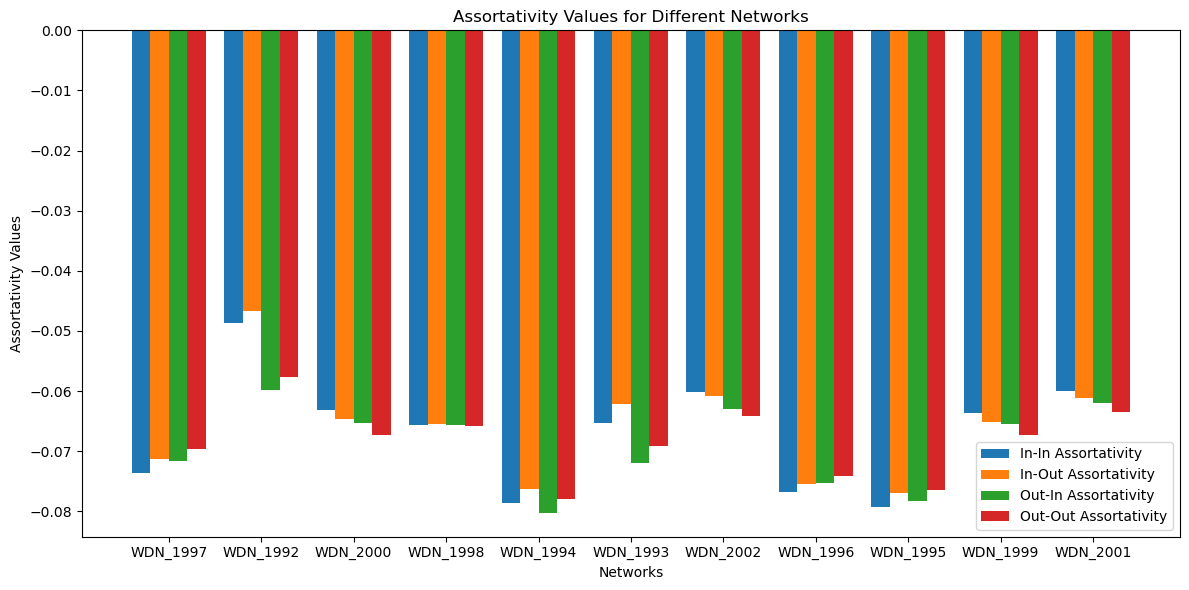

In [13]:
# Extracting graph names and assortativity values
graph_names = list(assortativities.keys())
keys = list(assortativities[graph_names[0]].keys())  # Extracting keys for assortativity values
values = {graph_name: [assortativities[graph_name][key] for key in keys] for graph_name in graph_names}

# Creating side-by-side bar plots for each network
bar_width = 0.2  # Width of each bar
index = np.arange(len(graph_names))  # Index for the networks

plt.figure(figsize=(12, 6))

for i, key in enumerate(keys):
    plt.bar(index + (i * bar_width), [values[graph_name][i] for graph_name in graph_names], bar_width, label=key)

plt.xlabel('Networks')
plt.ylabel('Assortativity Values')
plt.title('Assortativity Values for Different Networks')
plt.xticks(index + (bar_width * (len(keys) - 1) / 2), graph_names)
plt.legend()
plt.tight_layout()

plt.show()

## 2. Fit the Undirected Enhanced CM and Directed Enhanced CM using the CReMa method.
Hint: You can use the nemtropy package on networkx to deploy these methods. You can find some examples
at https://github.com/nicoloval/NEMtropy/blob/master/examples/Directed%20Graphs.
ipynb. For additional questions, do not hesitate to ask at the QA.

## 3. Sample 30 networks from the obtained ERGM distributions and measure the strength assortativity on all of them. Calculate average and standard deviation of each assortativity typology.

## 4. Plot strength assortativity as a function of time (the WTW network year), comparing the observed real value with the average and error bars obtained from the samples samples.
Hint: plot error bars as confidence intervals. Plot all pairs of assortativity for the undirected and directed
case(in-in, in-out, out-out)

## 5. Write a short paragraph to comment on the interpretation of strength assortativity for this dataset, and about the conclusions you can draw via the inference you made using the ERGM models.

Creating Results:
`jupyter nbconvert Assignment_03.ipynb --to pdf --output Assignment_03_Results.pdf`

# III Robustness

## 1. Generate synthetic networks (you can use whatever module you prefer):
1. Random networks (ErdosRényi) (with $n = 1000$ and $\langle k \rangle = \{1,4\}$)
2. Scale-free networks (Barabási-Albert) (with $n = 1000$ and $m = \{2,4\}$)

In [14]:
N = 1000
K_VALUES = range(1, 5, 1)
M_VALUES = range(2, 5, 1)
CONSIDERED_GRAPHS = ['graph_eu_airlines', 'graph_power']

In [15]:
er_graphs = {}
ba_graphs = {}

In [16]:
def generate_ER_graphs(nodes, k_values, number):
    graphs = {}
    
    # Generate n graphs for each k value
    for avg_degree in k_values:
        graphs[avg_degree] = {}
    
        for index in range(1, number+1, 1):
            
            probability = avg_degree / (nodes - 1)
            
            graph = nx.erdos_renyi_graph(n=nodes, p=probability)
            
            graphs[avg_degree][index] = graph
            
    return graphs

In [17]:
er_graphs = generate_ER_graphs(nodes=N, k_values=K_VALUES, number=2)
er_graphs

{1: {1: <networkx.classes.graph.Graph at 0x1212bb4d0>,
  2: <networkx.classes.graph.Graph at 0x121af26d0>},
 2: {1: <networkx.classes.graph.Graph at 0x1212e2690>,
  2: <networkx.classes.graph.Graph at 0x120726810>},
 3: {1: <networkx.classes.graph.Graph at 0x12009ff10>,
  2: <networkx.classes.graph.Graph at 0x12078ac90>},
 4: {1: <networkx.classes.graph.Graph at 0x11ff23cd0>,
  2: <networkx.classes.graph.Graph at 0x11f71a910>}}

In [18]:
def generate_BA_graphs(nodes, m_values, number):
    graphs = {}

    # Generate n graphs for each m value
    for m in m_values:
        graphs[m] = {}

        for index in range(1, number+1, 1):

            graph = nx.barabasi_albert_graph(n=nodes, m=m)

            graphs[m][index] = graph

    return graphs

In [19]:
ba_graphs = generate_BA_graphs(nodes=N, m_values=M_VALUES, number=2)
ba_graphs

{2: {1: <networkx.classes.graph.Graph at 0x1213140d0>,
  2: <networkx.classes.graph.Graph at 0x1206ddcd0>},
 3: {1: <networkx.classes.graph.Graph at 0x1206de090>,
  2: <networkx.classes.graph.Graph at 0x1206c2650>},
 4: {1: <networkx.classes.graph.Graph at 0x11f967fd0>,
  2: <networkx.classes.graph.Graph at 0x11f711e50>}}

## 2. Plot the degree distributions of the synthetic networks and of the networks provided in the datasets.

In [20]:
def plot_degree_distribution(ax, graph, color, param, graph_index, er):
    degrees = [degree for node, degree in graph.degree()]
    degree_freq = nx.degree_histogram(graph)
    ax.bar(range(len(degree_freq)), degree_freq, width=0.8, color=color)
    ax.set_xlabel('Degree')
    ax.set_ylabel('Frequency')
    if er:
        ax.set_title(fr"Degree Distribution of graph iteration {graph_index} with $\langle k \rangle = {param}$")
    else:
        ax.set_title(fr"Degree Distribution of graph iteration {graph_index} with $m = {param}$")
    

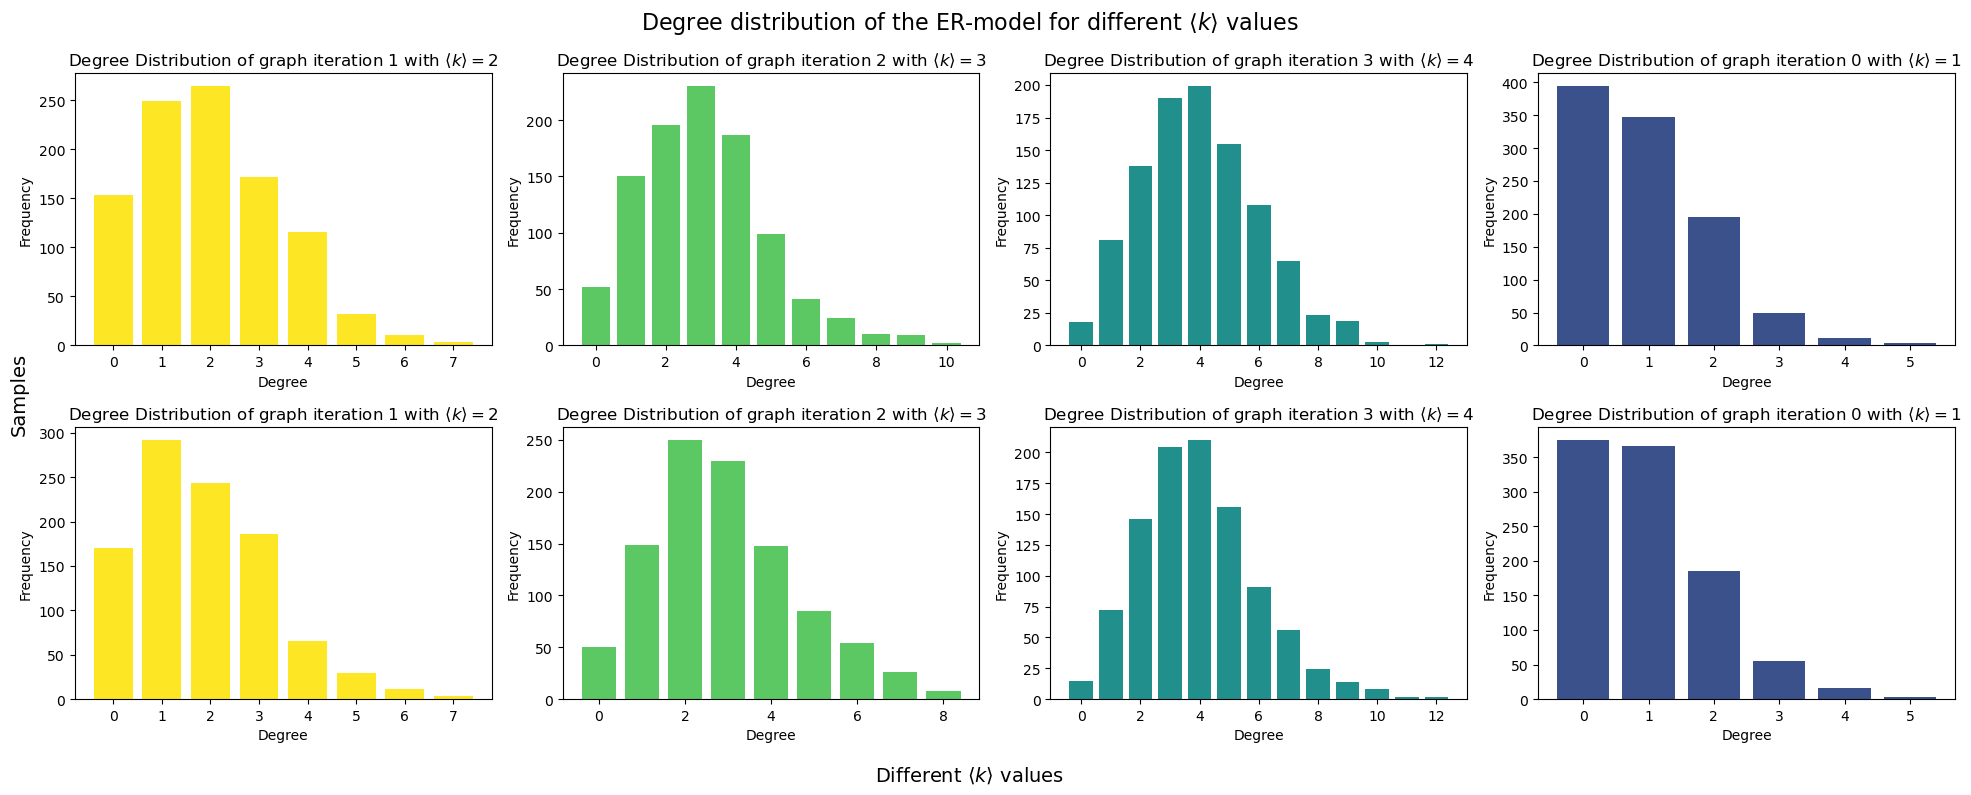

In [21]:
# ER-graphs
# Define colors for different average degrees using a colormap
num_avg_degrees = len(er_graphs)
colors = plt.cm.viridis_r([i / num_avg_degrees for i in range(num_avg_degrees)])

# Create a subplot grid
num_instances = len(next(iter(er_graphs.values())))  # Assuming all instances have the same count
fig, axs = plt.subplots(num_instances, num_avg_degrees, figsize=(20, 8))

# Iterate through avg_degree_index and graph_index
for avg_degree_index, (avg_degree, avg_degree_plots) in enumerate(er_graphs.items()):
    color = colors[avg_degree_index - 1]  # Get color for the degree
    for graph_index, graph in avg_degree_plots.items():
        # Get the appropriate axis for the subplot
        if num_instances == 1:
            ax = axs[avg_degree_index - 1]
        else:
            ax = axs[graph_index - 1, avg_degree_index - 1]

        # Plot on the corresponding axis with the assigned color
        plot_degree_distribution(ax=ax, graph=graph, color=color, param=avg_degree, graph_index=avg_degree_index, er=True)


fig.suptitle(fr"Degree distribution of the ER-model for different $\langle k \rangle$ values", fontsize=16)
fig.supxlabel(fr"Different $\langle k \rangle$ values", fontsize=14)
fig.supylabel("Samples", fontsize=14)


# Adjust layout and display the plot
plt.tight_layout()
plt.show()

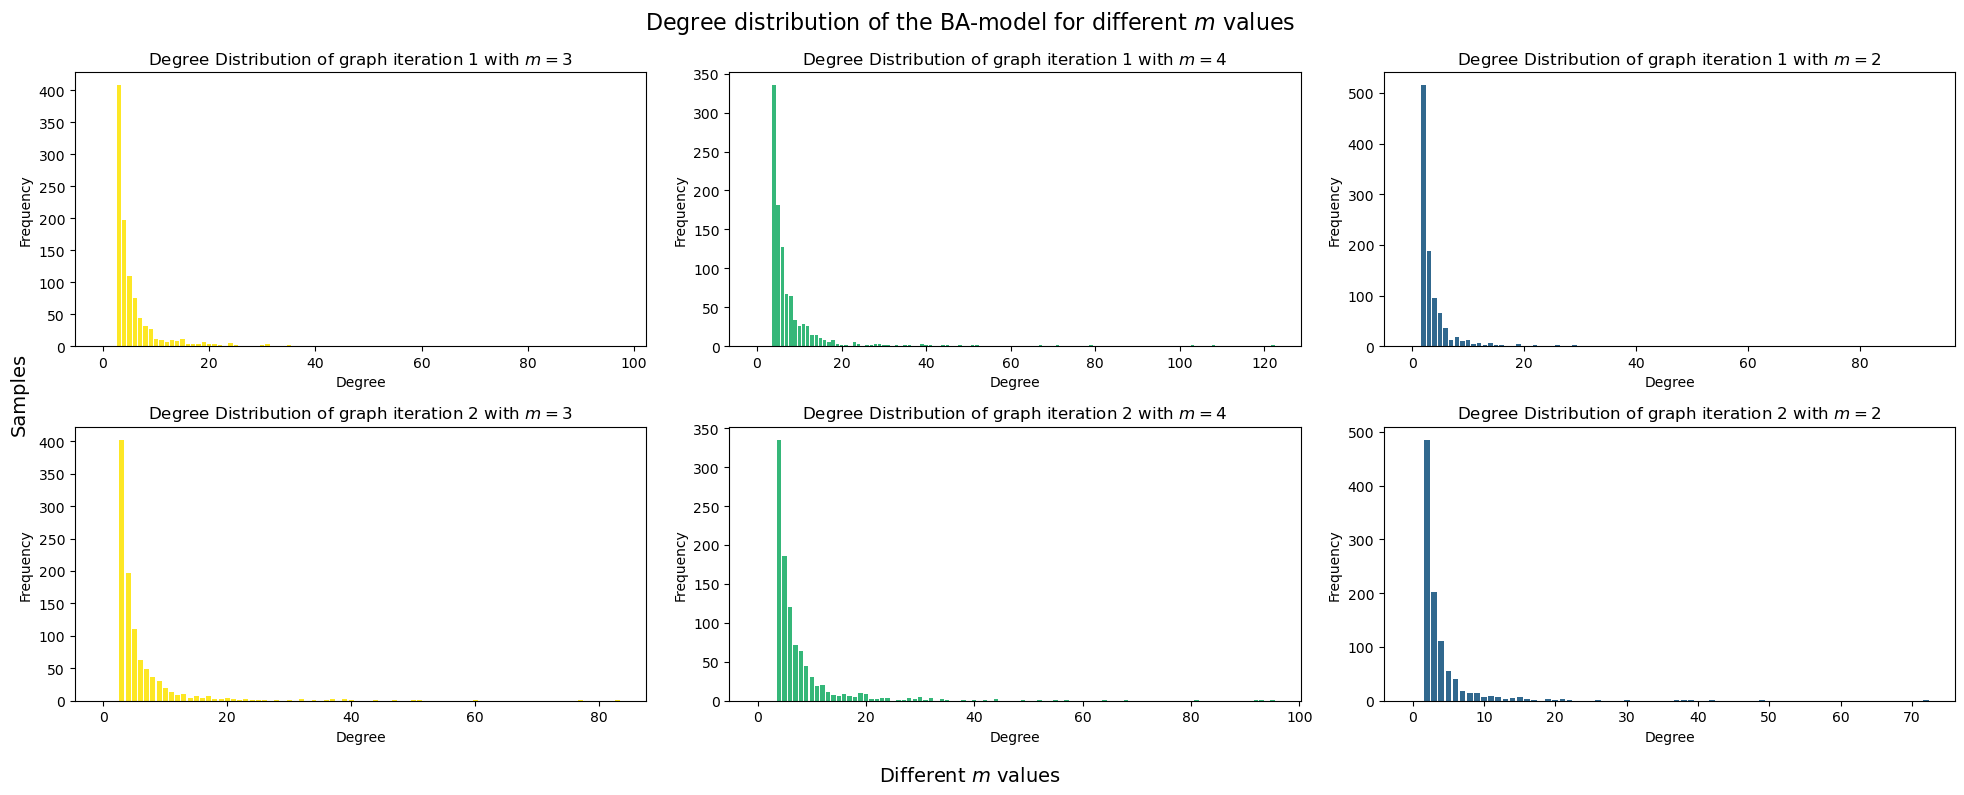

In [22]:
# BA-graphs
# Define colors for different average degrees using a colormap
num_ba_values = len(ba_graphs)
colors = plt.cm.viridis_r([i / num_ba_values for i in range(num_ba_values)])
# Create a subplot grid
num_instances = len(next(iter(ba_graphs.values())))  # Assuming all instances have the same count
fig, axs = plt.subplots(num_instances, num_ba_values, figsize=(20, 8))

# Iterate through avg_degree_index and graph_index
for m_index, (m, m_plots) in enumerate(ba_graphs.items()): # Do not forget that m is not an index -> use enumerate and m_index
    color = colors[m_index - 1]  # Get color for the degree
    for graph_index, graph in m_plots.items():
        # Get the appropriate axis for the subplot
        if num_instances == 1:
            ax = axs[m_index - 1]
        else:
            ax = axs[graph_index - 1, m_index - 1]

        # Plot on the corresponding axis with the assigned color
        plot_degree_distribution(ax=ax, graph=graph, color=color, param=m, graph_index=graph_index, er=False)

fig.suptitle(fr"Degree distribution of the BA-model for different $m$ values", fontsize=16)
fig.supxlabel(fr"Different $m$ values", fontsize=14)
fig.supylabel("Samples", fontsize=14)


# Adjust layout and display the plot
plt.tight_layout()
plt.show()

## 3. Plot the size of the largest connected component as a function of removed edges and nodes in two scenarios for the synthetic graphs and the real networks in the datasets:
(a) Random attacks (failures)
(b) Targeted attacks (degree centrality and betweenness centrality)

In [555]:
K_ESTIMATOR = 100

In [556]:
def remove_random_nodes(graph, n):
    # Copy it such that we do not need to import it again
    updated_graph = copy.deepcopy(graph)
    nodes_list = list(updated_graph.nodes())

    if len(nodes_list) < n:
        return graph, []

    extracted_nodes = []
    for _ in range(n):
        if nodes_list:
            random_node = random.choice(nodes_list)
            updated_graph.remove_node(random_node)
            extracted_nodes.append(random_node)
            nodes_list.remove(random_node)
        else:
            break
    
    # DEBUG
    # print(f"Removed nodes: {extracted_nodes}")
    return updated_graph, extracted_nodes

In [557]:
def remove_random_percentage_nodes(graph, percentage):
    if not 0 <= percentage <= 100:
        raise ValueError("Percentage should be between 0 and 100")

    num_nodes = len(graph.nodes())
    num_to_remove = int(num_nodes * (percentage / 100))

    return remove_random_nodes(graph, num_to_remove)

In [558]:
PERCENTAGES_TO_BE_REMOVED = [0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 50, 60, 80, 90]
#PERCENTAGES_TO_BE_REMOVED = [1,50]

In [559]:
TOP_N_TO_BE_REMOVED = [0,1,2,3,4,5,10]
#TOP_N_TO_BE_REMOVED = [1,2]

In [560]:
random_removed_graphs = {}

In [561]:
def generate_random_removed_graphs(graphs, percentages_to_be_removed, top_n_to_be_removed):
    random_removed_graphs = {}

    def process_graph(graph, graph_name, action, value):
        nonlocal random_removed_graphs
        if graph_name not in random_removed_graphs:
            random_removed_graphs[graph_name] = {}

        random_removed_graphs[graph_name][action] = {}
        updated_graph, extracted_nodes = value
        random_removed_graphs[graph_name][action]["graph"] = updated_graph
        removed_nodes = graph.number_of_nodes() - updated_graph.number_of_nodes()
        random_removed_graphs[graph_name][action]["reduced_nodes"] = removed_nodes
        print(f"{action} of graph {graph_name}")
        print(f"Graph {graph_name} has {graph.number_of_nodes()}")
        print(f"Graph (updated) {graph_name} has {updated_graph.number_of_nodes()}")
        print(f"Removed Nodes: {removed_nodes}")
        print("---")

    for graph_name, graph in graphs.items():
        for percentage in percentages_to_be_removed:
            action = str(percentage) + '%'
            process_graph(graph, graph_name, action, remove_random_percentage_nodes(graph=graph, percentage=percentage))

        for top_n in top_n_to_be_removed:
            action = f"top {top_n} nodes"
            process_graph(graph, graph_name, action, remove_random_nodes(graph=graph, n=top_n))

    return random_removed_graphs

In [562]:
random_removed_graphs = generate_random_removed_graphs(graphs=graphs, percentages_to_be_removed=PERCENTAGES_TO_BE_REMOVED, top_n_to_be_removed=TOP_N_TO_BE_REMOVED)

0% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 417
Removed Nodes: 0
---
1% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 413
Removed Nodes: 4
---
2% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 409
Removed Nodes: 8
---
3% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 405
Removed Nodes: 12
---
4% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 401
Removed Nodes: 16
---
5% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 397
Removed Nodes: 20
---
10% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 376
Removed Nodes: 41
---
15% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 355
Removed Nodes: 

In [563]:
def sort_nodes_by_degree_centrality(graph):
    degree_centrality = nx.degree_centrality(graph)
    sorted_by_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)
    return sorted_by_degree

In [564]:
def sort_nodes_by_betweenness_centrality(graph):
    betweenness_centrality = nx.betweenness_centrality(graph)
    sorted_by_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)
    return sorted_by_betweenness

In [565]:
def remove_targeted_nodes(graph, centrality_measure, n):
    if centrality_measure == 'degree':
        sorted_nodes = sorted(nx.degree_centrality(graph).items(), key=lambda x: x[1], reverse=True)
    elif centrality_measure == 'betweenness':
        sorted_nodes = sorted(nx.betweenness_centrality(graph, k=K_ESTIMATOR).items(), key=lambda x: x[1], reverse=True)
    else:
        raise ValueError("Centrality measure should be 'degree' or 'betweenness'")

    updated_graph = copy.deepcopy(graph)

    if len(sorted_nodes) < n:
        return graph, []

    extracted_nodes = []
    for i in range(n):
        node = sorted_nodes[i][0]  # Extracting node from the sorted list
        updated_graph.remove_node(node)
        extracted_nodes.append(node)

    # DEBUG
    # print(f"Removed nodes: {extracted_nodes}")
    return updated_graph, extracted_nodes

In [566]:
def remove_target_percentage_nodes(graph, centrality_measure, percentage):
    if not 0 <= percentage <= 100:
        raise ValueError("Percentage should be between 0 and 100")

    num_nodes = len(graph.nodes())
    num_to_remove = int(num_nodes * (percentage / 100))

    return remove_targeted_nodes(graph, centrality_measure, num_to_remove)

In [567]:
target_degree_centrality_removed_graphs = {}

In [568]:
def generate_target_degree_centrality_removed_graphs(graphs, percentages_to_be_removed, top_n_to_be_removed):
    target_degree_centrality_removed_graphs = {}

    def process_graph(graph, graph_name, action, value):
        nonlocal target_degree_centrality_removed_graphs
        if graph_name not in target_degree_centrality_removed_graphs:
            target_degree_centrality_removed_graphs[graph_name] = {}

        target_degree_centrality_removed_graphs[graph_name][action] = {}
        updated_graph, extracted_nodes = value
        target_degree_centrality_removed_graphs[graph_name][action]["graph"] = updated_graph
        removed_nodes = graph.number_of_nodes() - updated_graph.number_of_nodes()
        target_degree_centrality_removed_graphs[graph_name][action]["reduced_nodes"] = removed_nodes
        print(f"{action} of graph {graph_name}")
        print(f"Graph {graph_name} has {graph.number_of_nodes()}")
        print(f"Graph (updated) {graph_name} has {updated_graph.number_of_nodes()}")
        print(f"Removed Nodes: {removed_nodes}")
        print("---")

    for graph_name, graph in graphs.items():
        for percentage in percentages_to_be_removed:
            action = str(percentage) + '%'
            process_graph(graph, graph_name, action, remove_target_percentage_nodes(graph=graph, centrality_measure='degree', percentage=percentage))

        for top_n in top_n_to_be_removed:
            action = f"top {top_n} nodes"
            process_graph(graph, graph_name, action, remove_targeted_nodes(graph=graph, centrality_measure='degree', n=top_n))

    return target_degree_centrality_removed_graphs

In [569]:
target_degree_centrality_removed_graphs = generate_target_degree_centrality_removed_graphs(graphs=graphs, percentages_to_be_removed=PERCENTAGES_TO_BE_REMOVED, top_n_to_be_removed=TOP_N_TO_BE_REMOVED)

0% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 417
Removed Nodes: 0
---
1% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 413
Removed Nodes: 4
---
2% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 409
Removed Nodes: 8
---
3% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 405
Removed Nodes: 12
---
4% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 401
Removed Nodes: 16
---
5% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 397
Removed Nodes: 20
---
10% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 376
Removed Nodes: 41
---
15% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 355
Removed Nodes: 

In [570]:
target_betweenness_centrality_removed_graphs = {}

In [571]:
def generate_target_betweenness_centrality_removed_graphs(graphs, percentages_to_be_removed, top_n_to_be_removed):
    target_betweenness_centrality_removed_graphs = {}

    def process_graph(graph, graph_name, action, value):
        nonlocal target_betweenness_centrality_removed_graphs
        if graph_name not in target_betweenness_centrality_removed_graphs:
            target_betweenness_centrality_removed_graphs[graph_name] = {}

        target_betweenness_centrality_removed_graphs[graph_name][action] = {}
        updated_graph, extracted_nodes = value
        target_betweenness_centrality_removed_graphs[graph_name][action]["graph"] = updated_graph
        removed_nodes = graph.number_of_nodes() - updated_graph.number_of_nodes()
        target_betweenness_centrality_removed_graphs[graph_name][action]["reduced_nodes"] = removed_nodes
        print(f"{action} of graph {graph_name}")
        print(f"Graph {graph_name} has {graph.number_of_nodes()}")
        print(f"Graph (updated) {graph_name} has {updated_graph.number_of_nodes()}")
        print(f"Removed Nodes: {removed_nodes}")
        print("---")

    for graph_name, graph in graphs.items():
        for percentage in percentages_to_be_removed:
            action = str(percentage) + '%'
            process_graph(graph, graph_name, action, remove_target_percentage_nodes(graph=graph, centrality_measure='betweenness', percentage=percentage))

        for top_n in top_n_to_be_removed:
            action = f"top {top_n} nodes"
            process_graph(graph, graph_name, action, remove_targeted_nodes(graph=graph, centrality_measure='betweenness', n=top_n))

    return target_betweenness_centrality_removed_graphs


In [572]:
target_betweenness_centrality_removed_graphs = generate_target_betweenness_centrality_removed_graphs(graphs=graphs, percentages_to_be_removed=PERCENTAGES_TO_BE_REMOVED, top_n_to_be_removed=TOP_N_TO_BE_REMOVED)

0% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 417
Removed Nodes: 0
---
1% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 413
Removed Nodes: 4
---
2% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 409
Removed Nodes: 8
---
3% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 405
Removed Nodes: 12
---
4% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 401
Removed Nodes: 16
---
5% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 397
Removed Nodes: 20
---
10% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 376
Removed Nodes: 41
---
15% of graph graph_eu_airlines
Graph graph_eu_airlines has 417
Graph (updated) graph_eu_airlines has 355
Removed Nodes: 

In [573]:
random_removed_graphs

{'graph_eu_airlines': {'0%': {'graph': <networkx.classes.graph.Graph at 0x130fddfd0>,
   'reduced_nodes': 0},
  '1%': {'graph': <networkx.classes.graph.Graph at 0x137f551d0>,
   'reduced_nodes': 4},
  '2%': {'graph': <networkx.classes.graph.Graph at 0x131621150>,
   'reduced_nodes': 8},
  '3%': {'graph': <networkx.classes.graph.Graph at 0x141a93690>,
   'reduced_nodes': 12},
  '4%': {'graph': <networkx.classes.graph.Graph at 0x13671f710>,
   'reduced_nodes': 16},
  '5%': {'graph': <networkx.classes.graph.Graph at 0x12f02bf50>,
   'reduced_nodes': 20},
  '10%': {'graph': <networkx.classes.graph.Graph at 0x12f02a290>,
   'reduced_nodes': 41},
  '15%': {'graph': <networkx.classes.graph.Graph at 0x13d01a190>,
   'reduced_nodes': 62},
  '20%': {'graph': <networkx.classes.graph.Graph at 0x1377b5f90>,
   'reduced_nodes': 83},
  '25%': {'graph': <networkx.classes.graph.Graph at 0x137efc610>,
   'reduced_nodes': 104},
  '30%': {'graph': <networkx.classes.graph.Graph at 0x1349ccd90>,
   'reduced

In [574]:
plot_data_random = {}

In [575]:
def generate_plot_data(graphs):
    plot_data = {}

    for graph_name, cases in graphs.items():
        print(f"Graph: {graph_name}")
        plot_data[graph_name] = {
            'percentage': {'x_percentages_removed': [], 'y_size_lcc': [], 'y_size_lcc_frac': []},
            'absolute': {'x_absolute_removed': [], 'y_size_lcc': [], 'y_size_lcc_frac': []}
        }

        for case, data in cases.items():
            graph = data['graph']
            largest_cc = max(nx.connected_components(graph), key=len)
            largest_connected_component = graph.subgraph(largest_cc)
            size_largest_cc = len(largest_connected_component)

            print(f"Case: {case}")
            print(f"Size of largest connected component: {size_largest_cc}")
            if '%' in str(case):
                plot_data[graph_name]['percentage']['x_percentages_removed'].append(int(str(case).replace('%', ''))/100)
                plot_data[graph_name]['percentage']['y_size_lcc'].append(size_largest_cc)
                plot_data[graph_name]['percentage']['y_size_lcc_frac'].append(size_largest_cc/plot_data[graph_name]['percentage']['y_size_lcc'][0])
            else:
                plot_data[graph_name]['absolute']['x_absolute_removed'].append(case)
                plot_data[graph_name]['absolute']['y_size_lcc'].append(size_largest_cc)
                plot_data[graph_name]['absolute']['y_size_lcc_frac'].append(size_largest_cc/plot_data[graph_name]['absolute']['y_size_lcc'][0])

            print()

    return plot_data


In [576]:
plot_data_random = generate_plot_data(random_removed_graphs)

Graph: graph_eu_airlines
Case: 0%
Size of largest connected component: 417

Case: 1%
Size of largest connected component: 413

Case: 2%
Size of largest connected component: 409

Case: 3%
Size of largest connected component: 398

Case: 4%
Size of largest connected component: 401

Case: 5%
Size of largest connected component: 392

Case: 10%
Size of largest connected component: 370

Case: 15%
Size of largest connected component: 337

Case: 20%
Size of largest connected component: 328

Case: 25%
Size of largest connected component: 298

Case: 30%
Size of largest connected component: 244

Case: 50%
Size of largest connected component: 175

Case: 60%
Size of largest connected component: 140

Case: 80%
Size of largest connected component: 50

Case: 90%
Size of largest connected component: 16

Case: top 0 nodes
Size of largest connected component: 417

Case: top 1 nodes
Size of largest connected component: 416

Case: top 2 nodes
Size of largest connected component: 415

Case: top 3 nodes
Size 

In [577]:
plot_data_random

{'graph_eu_airlines': {'percentage': {'x_percentages_removed': [0.0,
    0.01,
    0.02,
    0.03,
    0.04,
    0.05,
    0.1,
    0.15,
    0.2,
    0.25,
    0.3,
    0.5,
    0.6,
    0.8,
    0.9],
   'y_size_lcc': [417,
    413,
    409,
    398,
    401,
    392,
    370,
    337,
    328,
    298,
    244,
    175,
    140,
    50,
    16],
   'y_size_lcc_frac': [1.0,
    0.9904076738609112,
    0.9808153477218226,
    0.9544364508393285,
    0.9616306954436451,
    0.9400479616306955,
    0.8872901678657075,
    0.8081534772182254,
    0.7865707434052758,
    0.7146282973621103,
    0.5851318944844125,
    0.4196642685851319,
    0.33573141486810554,
    0.11990407673860912,
    0.03836930455635491]},
  'absolute': {'x_absolute_removed': ['top 0 nodes',
    'top 1 nodes',
    'top 2 nodes',
    'top 3 nodes',
    'top 4 nodes',
    'top 5 nodes',
    'top 10 nodes'],
   'y_size_lcc': [417, 416, 415, 414, 412, 412, 407],
   'y_size_lcc_frac': [1.0,
    0.9976019184652278,
    0

In [578]:
def percent_formatter(x, pos):
    return '{:.0%}'.format(x)

In [579]:
def plot_removed_data(plot_data, title):
    fig, axs = plt.subplots(2, 2, figsize=(12, 6))
    for graph_name, data in plot_data.items():
        # x: percentage of removed nodes, y: absolute size of lcc after removal
        axs[0, 0].scatter(data['percentage']['x_percentages_removed'],
                          data['percentage']['y_size_lcc'],
                          label=graph_name, marker='o')

        # x: absolute removed nodes, y: absolute size of lcc after removal
        axs[0, 1].scatter(data['absolute']['x_absolute_removed'],
                          data['absolute']['y_size_lcc'],
                          label=graph_name, marker='o')

        # x: percentage of removed nodes, y: percentage of lcc after removal (lcc / lcc_before_removal)
        axs[1, 0].scatter(data['percentage']['x_percentages_removed'],
                          data['percentage']['y_size_lcc_frac'],
                          label=graph_name, marker='o')

        # x: absolute removed nodes, y: percentage of lcc after removal (lcc / lcc_before_removal)
        axs[1, 1].scatter(data['absolute']['x_absolute_removed'],
                          data['absolute']['y_size_lcc_frac'],
                          label=graph_name, marker='o')

    # Set x-axis and y-axis labels for each subplot
    axs[0, 0].set_xlabel('% removed nodes')
    axs[0, 0].set_ylabel('# nodes of lcc')

    axs[0, 1].set_xlabel('# removed nodes')
    axs[0, 1].set_ylabel('# nodes of lcc')

    axs[1, 0].set_xlabel('% removed nodes')
    axs[1, 0].set_ylabel('relative size lcc after removal (%)')

    axs[1, 1].set_xlabel('# removed nodes')
    axs[1, 1].set_ylabel('relative size lcc after removal (%)')

    plt.suptitle(title, fontsize=16)

    axs[0, 0].xaxis.set_major_formatter(FuncFormatter(percent_formatter))
    axs[1, 0].xaxis.set_major_formatter(FuncFormatter(percent_formatter))
    axs[0, 0].set_title('Absolute')
    axs[0, 1].set_title('Absolute')
    axs[1, 0].set_title('Percentage')
    axs[1, 1].set_title('Percentage')

    # Get handles and labels for all scatter plots
    handles, labels = axs[0, 0].get_legend_handles_labels()

    # Create a legend for all scatter plots using handles and labels collected above
    plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(-0.25, -0.25))
    plt.tight_layout()
    plt.show()

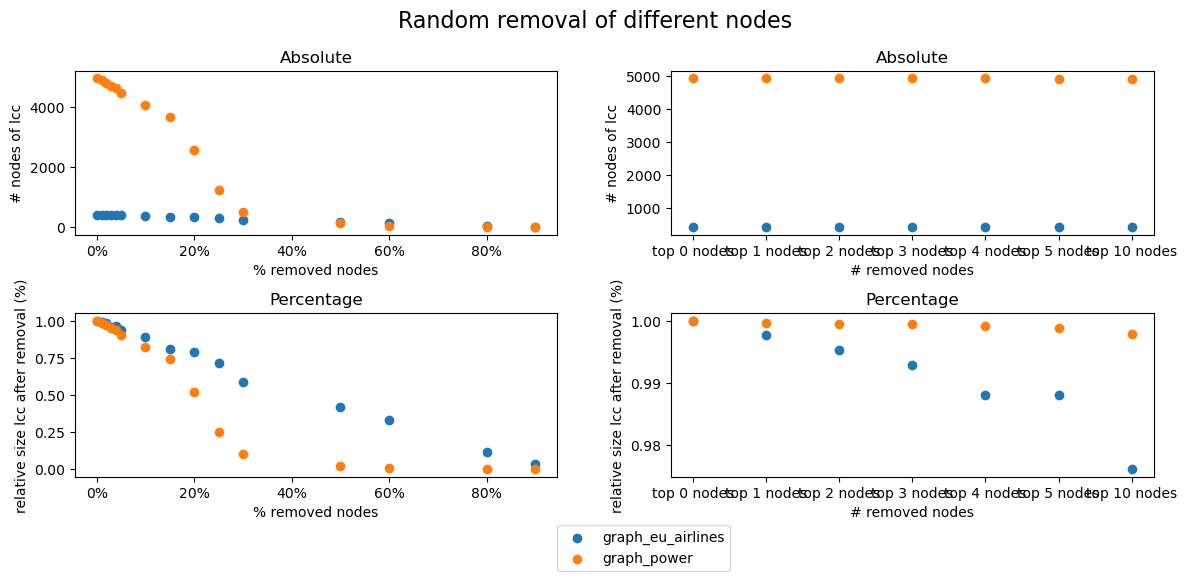

In [580]:
plot_removed_data(plot_data_random, 'Random removal of different nodes')

In [581]:
plot_data_betweenness = generate_plot_data(target_betweenness_centrality_removed_graphs)

Graph: graph_eu_airlines
Case: 0%
Size of largest connected component: 417

Case: 1%
Size of largest connected component: 388

Case: 2%
Size of largest connected component: 365

Case: 3%
Size of largest connected component: 359

Case: 4%
Size of largest connected component: 331

Case: 5%
Size of largest connected component: 329

Case: 10%
Size of largest connected component: 263

Case: 15%
Size of largest connected component: 196

Case: 20%
Size of largest connected component: 138

Case: 25%
Size of largest connected component: 79

Case: 30%
Size of largest connected component: 18

Case: 50%
Size of largest connected component: 5

Case: 60%
Size of largest connected component: 3

Case: 80%
Size of largest connected component: 3

Case: 90%
Size of largest connected component: 2

Case: top 0 nodes
Size of largest connected component: 417

Case: top 1 nodes
Size of largest connected component: 416

Case: top 2 nodes
Size of largest connected component: 409

Case: top 3 nodes
Size of large

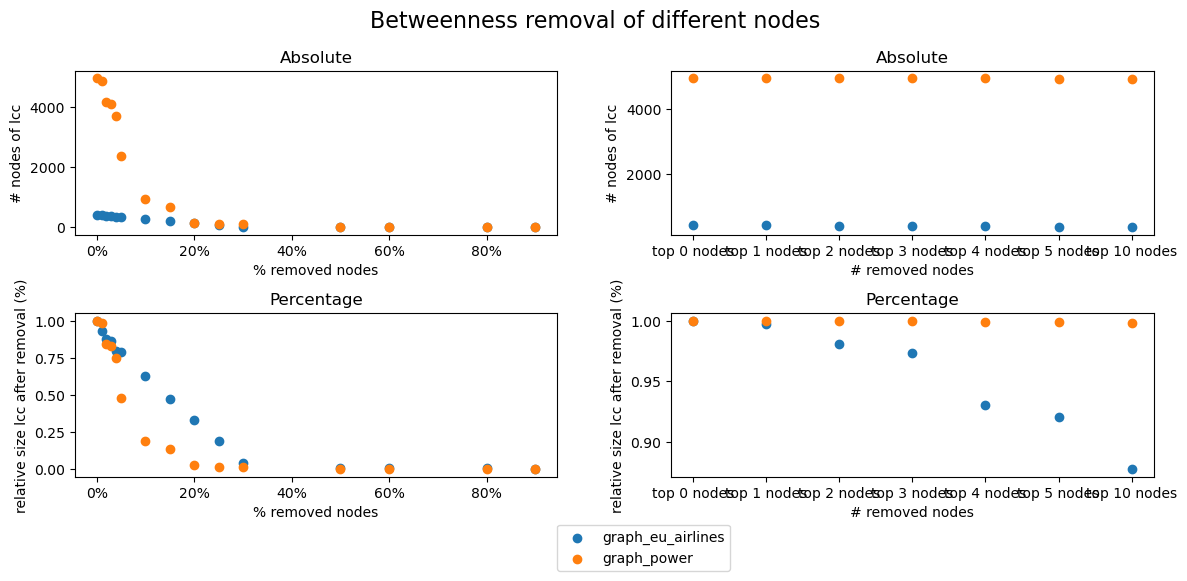

In [582]:
plot_removed_data(plot_data_betweenness, 'Betweenness removal of different nodes')

In [583]:
plot_data_degree = generate_plot_data(target_degree_centrality_removed_graphs)

Graph: graph_eu_airlines
Case: 0%
Size of largest connected component: 417

Case: 1%
Size of largest connected component: 408

Case: 2%
Size of largest connected component: 396

Case: 3%
Size of largest connected component: 381

Case: 4%
Size of largest connected component: 357

Case: 5%
Size of largest connected component: 346

Case: 10%
Size of largest connected component: 282

Case: 15%
Size of largest connected component: 233

Case: 20%
Size of largest connected component: 164

Case: 25%
Size of largest connected component: 68

Case: 30%
Size of largest connected component: 20

Case: 50%
Size of largest connected component: 6

Case: 60%
Size of largest connected component: 5

Case: 80%
Size of largest connected component: 1

Case: 90%
Size of largest connected component: 1

Case: top 0 nodes
Size of largest connected component: 417

Case: top 1 nodes
Size of largest connected component: 414

Case: top 2 nodes
Size of largest connected component: 410

Case: top 3 nodes
Size of large

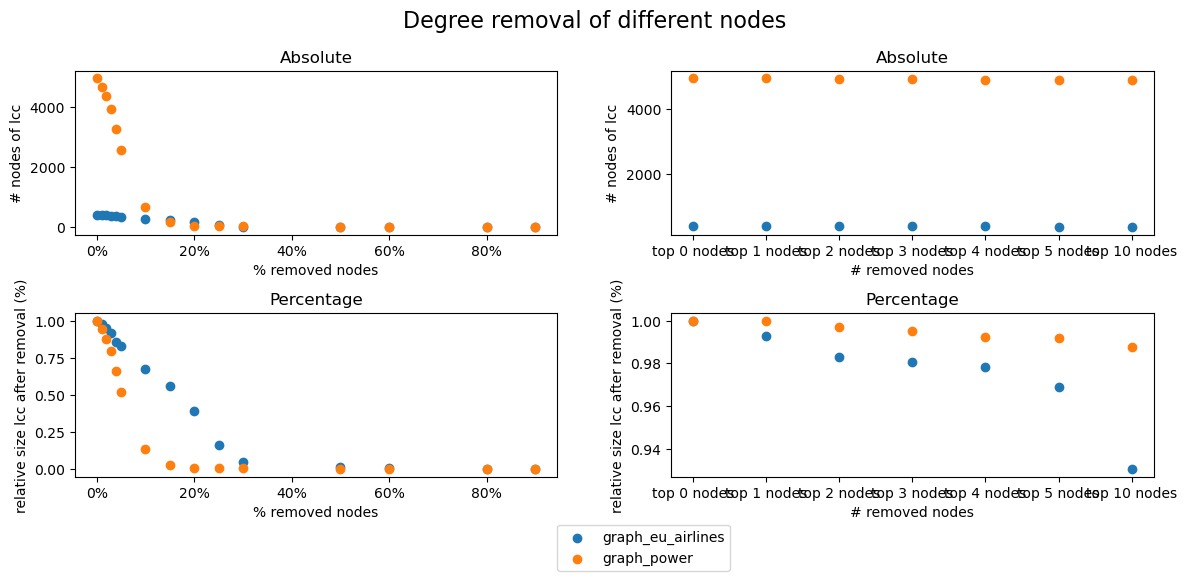

In [584]:
plot_removed_data(plot_data_degree, 'Degree removal of different nodes')

## 4. Comment the plots, using what we discussed in class.